In [62]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error as mse

# Загрузка изображения

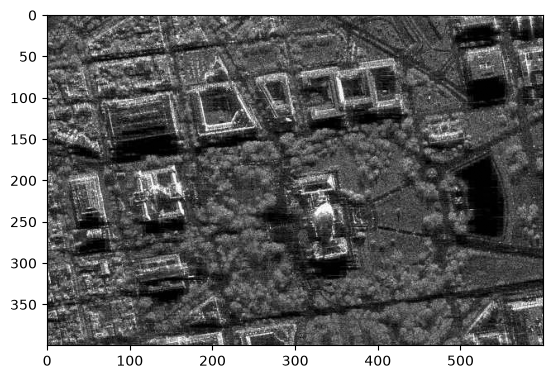

In [63]:
image = cv2.imread("sar_1_gray.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")

# Построение гистограммы

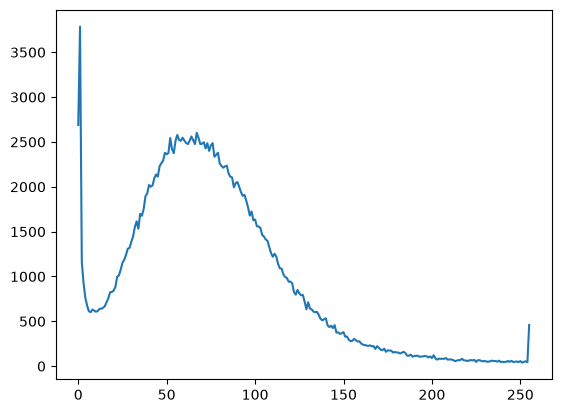

In [64]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

plt.plot(b_hist)

# Алгоритм гамма коррекции

In [65]:
def gamma_correction(image, gamma):
    inv_gamma = 1 / gamma
    table = np.array([
        ((i / 255) ** inv_gamma) * 255
        for i in np.arange(0, 256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

## Гамма коррекция >1

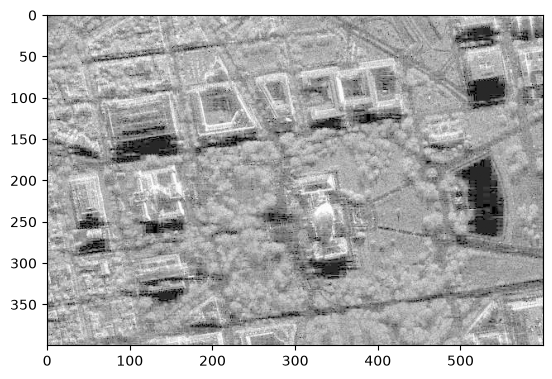

In [66]:
correction_1 = gamma_correction(image, 3)
plt.imshow(correction_1, cmap="gray")

## Гамма коррекция <1

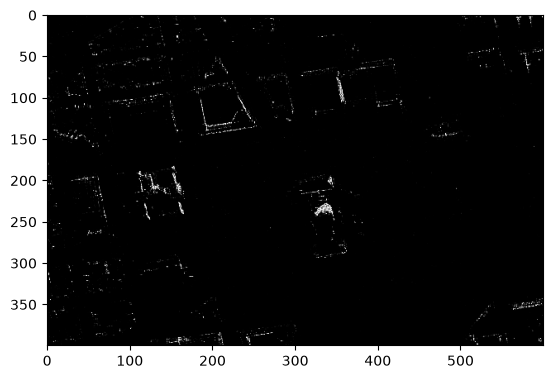

In [67]:
correction_2 = gamma_correction(image, 0.1)
plt.imshow(correction_2, cmap="gray")

# SSIM, MSE

In [68]:
ssim_correction_1 = ssim(image, correction_1)
mse_correction_1 = mse(image, correction_1)

ssim_correction_2 = ssim(image, correction_2)
mse_correction_2 = mse(image, correction_2)

print("MSE correction_1: ", mse_correction_1)
print("SSIM correction_1: ", ssim_correction_1)

print("MSE correction_2: ", mse_correction_2)
print("SSIM correction_2: ", ssim_correction_2)

MSE correction_1:  7637.051045833334
SSIM correction_1:  0.6542966529630305
MSE correction_2:  6900.058620833333
SSIM correction_2:  0.029825955116113703


# Алгоритм статистической цветокоррекции на основе статистики eq_gray

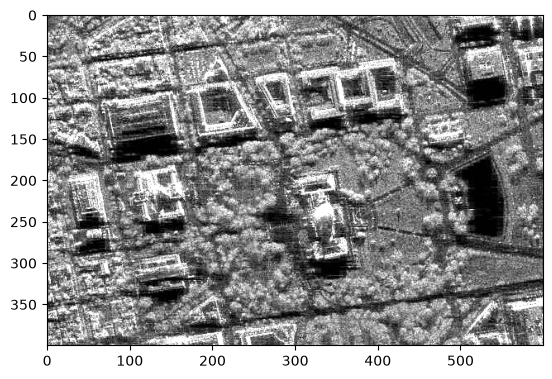

In [ ]:
def correction(image, ref):
    mu_s, sd_s = image.mean(), image.std()
    mu_r, sd_r = ref.mean(), ref.std()
    return np.clip((image - mu_s) * (sd_r / sd_s) + mu_r, 0, 255).astype(np.uint8)

eq_gray = cv2.equalizeHist(image)
res = correction(image, eq_gray)


plt.imshow(res, cmap="gray")

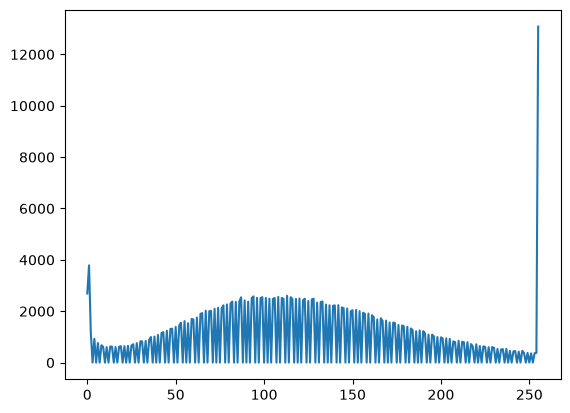

In [ ]:
hist = cv2.calcHist([res], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(hist)

# Пороговая фильтрация

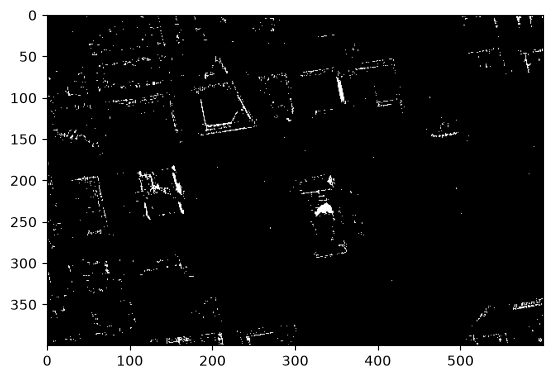

In [71]:
_, th_bin = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)
plt.imshow(th_bin, cmap="gray")
plt.show()

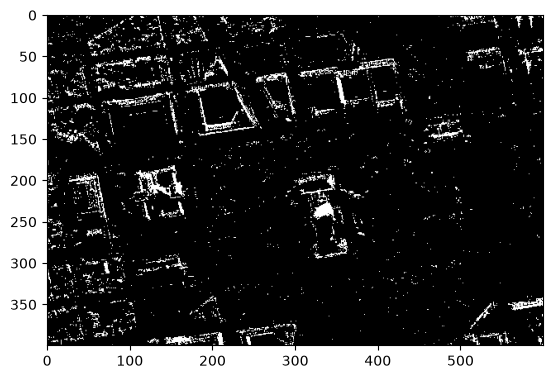

In [72]:
_, th_bin = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)
plt.imshow(th_bin, cmap="gray")
plt.show()

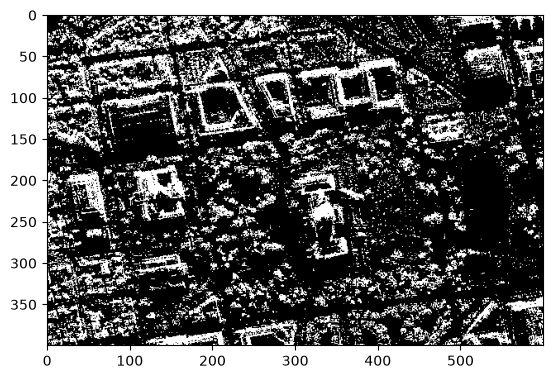

In [73]:
_, th_bin = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY)
plt.imshow(th_bin, cmap="gray")
plt.show()